#**DECISION TREE**


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,f1_score, recall_score, roc_auc_score,confusion_matrix

In [ ]:
#import Data set
file = pd.ExcelFile("heart_disease.xlsx")
abd =pd.read_excel(file,'Description')
df =pd.read_excel(file,'Heart_disease')

In [ ]:
df.shape

(908, 13)

In [ ]:
# Quick look
print(df.head())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  


In [ ]:
print(abd)

         age                                       Age in years
0     Gender                       Gender ; Male - 1, Female -0
1         cp                                    Chest pain type
2   trestbps                             Resting blood pressure
3       chol                                cholesterol measure
4        fbs  (fasting blood sugar > 120 mg/dl) (1 = true; 0...
5    restecg  ecg observation at resting condition,   -- Val...
6     thalch                        maximum heart rate achieved
7      exang                            exercise induced angina
8    oldpeak  ST depression induced by exercise relative to ...
9      slope          the slope of the peak exercise ST segment
10      thal                                               Thal
11       num  target [0=no heart disease; 1,2,3,4 = stages o...


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,908.0,53.791850,9.158031,29.0,47.75,54.0,60.0,77.0
trestbps,908.0,133.430617,20.401608,0.0,120.00,130.0,144.0,200.0
chol,908.0,201.484581,112.097949,0.0,176.75,224.0,270.0,603.0
thalch,908.0,135.957048,26.804929,60.0,118.00,138.0,156.0,202.0
oldpeak,846.0,0.891253,1.093875,-2.6,0.00,0.5,1.5,6.2
num,908.0,1.008811,1.144436,0.0,0.00,1.0,2.0,4.0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None


###**2.Exploratory Data Analysis (EDA)**


In [ ]:
# Check missing values
print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [ ]:
#For Duplicates
df.duplicated().any()

np.True_

In [ ]:
#Droping Duplicate Data
df.drop_duplicates(inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


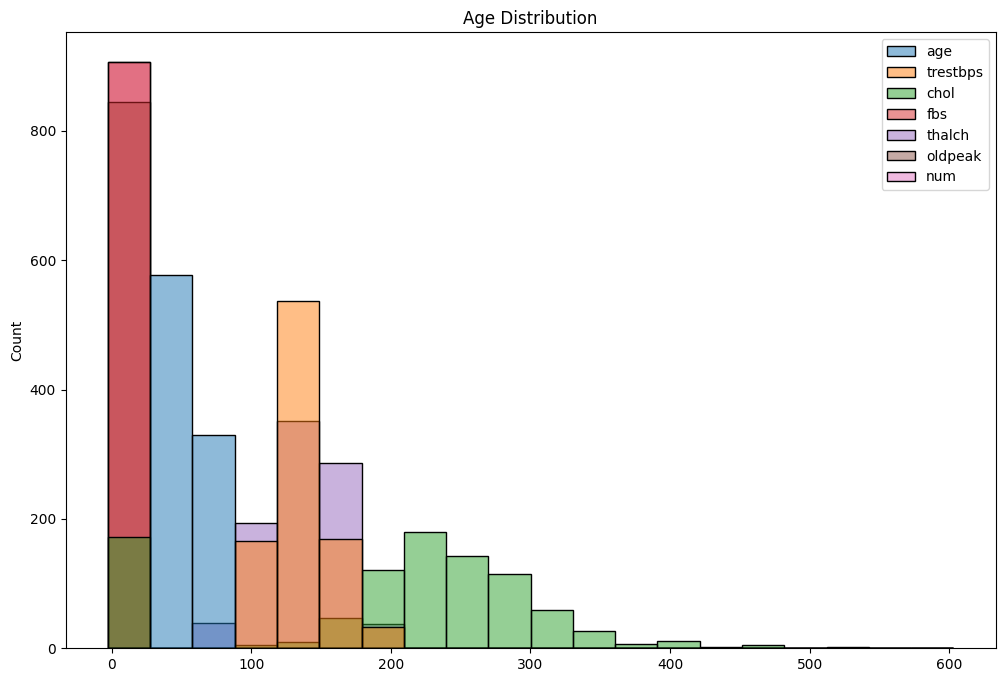

In [ ]:
# Visualizations
plt.figure(figsize=(12,8))
sns.histplot(df, bins=20)
plt.title("Age Distribution")
plt.show()

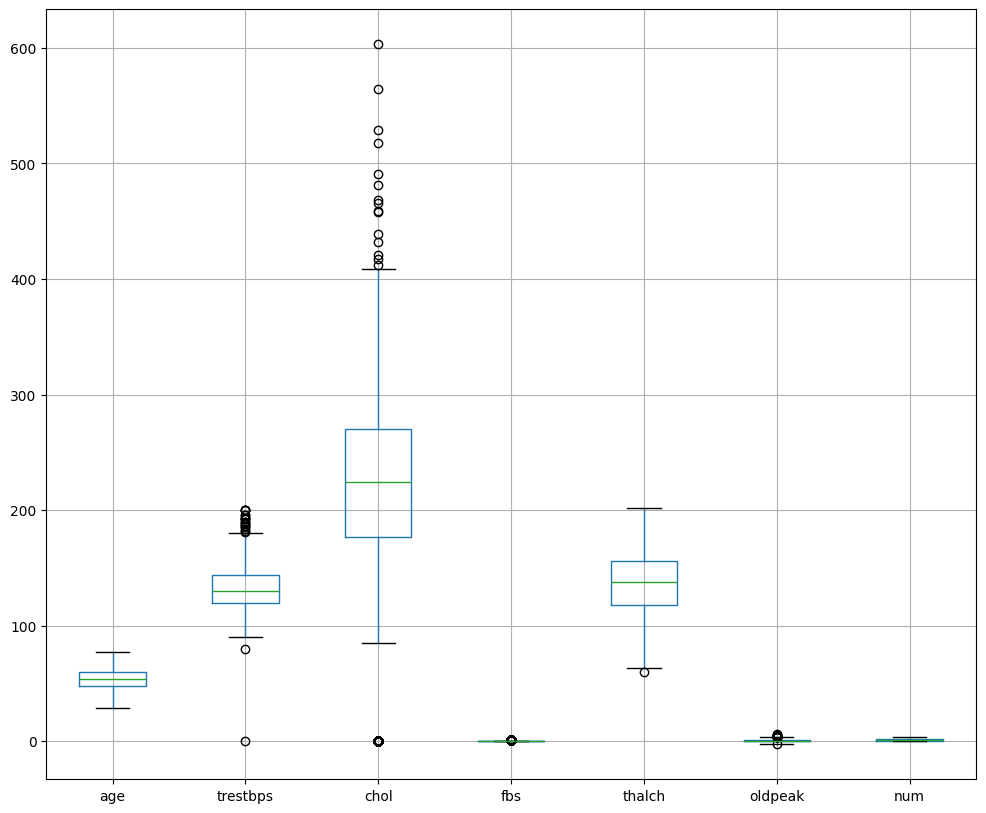

In [ ]:
df.boxplot(figsize=(12,10))
plt.show()

In [ ]:
#correlation Matrices
cat_col=df.select_dtypes(include=['object']).columns.tolist()
num_col=df.select_dtypes(include=['float64','int64']).columns.tolist()

In [ ]:
# Correlatino matrix for numerical columns
num_corr=df[num_col].corr()

In [ ]:
# Display the correlation matrix
print("Correlation matrix for numerical variables:")
print(num_corr)

Correlation matrix for numerical variables:
               age  trestbps      chol    thalch   oldpeak       num
age       1.000000  0.253709 -0.100059 -0.327868  0.243280  0.326227
trestbps  0.253709  1.000000  0.117392 -0.132841  0.168160  0.136581
chol     -0.100059  0.117392  1.000000  0.198074  0.030052 -0.239065
thalch   -0.327868 -0.132841  0.198074  1.000000 -0.140423 -0.322632
oldpeak   0.243280  0.168160  0.030052 -0.140423  1.000000  0.438834
num       0.326227  0.136581 -0.239065 -0.322632  0.438834  1.000000


###**Featre Engineering**

In [ ]:
# Scaling numerical features

scaler = StandardScaler()
df[df.select_dtypes(include=['int64', 'float64']).columns] = scaler.fit_transform(df.select_dtypes(include=['int64', 'float64']))

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


###**Decision Tree Model**

In [ ]:
# Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)
df.isnull().any()

,0
age,False
trestbps,False
chol,False
fbs,False
thalch,False
oldpeak,True
num,False
sex_Male,False
cp_atypical angina,False
cp_non-anginal,False


In [ ]:
df['num']

,num
0,-0.880901
1,-0.880901
2,-0.880901
3,-0.880901
4,-0.880901
...,...
903,2.615717
904,2.615717
905,2.615717
906,2.615717


In [ ]:
# Split the dataset into training and testing
df['num'] = (df['num'] > 0).astype(int)
X = df.drop('num', axis=1)
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Implementing a Decision Tree Classification model
model = DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [ ]:
# Create an imputer object
imputer = SimpleImputer(strategy='mean')

In [ ]:
# Train the model on the training set
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [ ]:
# Evaluate the model on the testing set
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred)
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', recall)
print('F1 Score:', f1)
print('ROC-AUC:', roc_auc)

Accuracy: 0.7967032967032966
Precision: 0.7867876392254822
Recall: 0.7967032967032966
F1 Score: 0.7636590833915249
ROC-AUC: 0.6337915601023019


###Hyperparameter Tuning:

In [ ]:
# Defining the grid of hyperparameters
grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'criterion': ['entropy', 'gini']
}

In [ ]:
# Creating a DecisionTreeClassifier instance
dtc=DecisionTreeClassifier()

In [ ]:
grid_search = GridSearchCV(estimator=dtc, param_grid=grid, cv=5)

In [ ]:
# Fit the grid search object to the training data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [3, 5, 7, 9],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
# Get the best hyperparameters
best_params= grid_search.best_params_
best_params

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

In [ ]:
# Get the best model
best_mod= grid_search.best_estimator_
best_mod

DecisionTreeClassifier(max_depth=3)

In [ ]:
# Evaluate the best model on the testing data
y_pred = best_mod.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred)

In [ ]:
print('Best Hyperparameters:')
print(best_params)

print('\nAccuracy:', acc)
print('Precision:', prec)
print('Recall:', recall)
print('F1 Score:', f1)
print('ROC-AUC:', roc_auc)


Best Hyperparameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

Accuracy: 0.7857142857142857
Precision: 0.7716832187420423
Recall: 0.7857142857142857
F1 Score: 0.7467172915677899
ROC-AUC: 0.6120524296675193


###Model Evaluation and Analysis

In [ ]:
# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[131   5]
 [ 34  12]]


In [ ]:
# Feature importance
importance = best_mod.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance[i]}")

age: 0.11852263802430817
trestbps: 0.05074005633731828
chol: 0.3138815036489042
fbs: 0.0
thalch: 0.06928773496893474
oldpeak: 0.34713799364971215
sex_Male: 0.0
cp_atypical angina: 0.0
cp_non-anginal: 0.0
cp_typical angina: 0.0
restecg_normal: 0.0
restecg_st-t abnormality: 0.0
exang_True: 0.10043007337082238
exang_FALSE: 0.0
exang_TURE: 0.0
slope_flat: 0.0
slope_upsloping: 0.0
thal_normal: 0.0
thal_reversable defect: 0.0


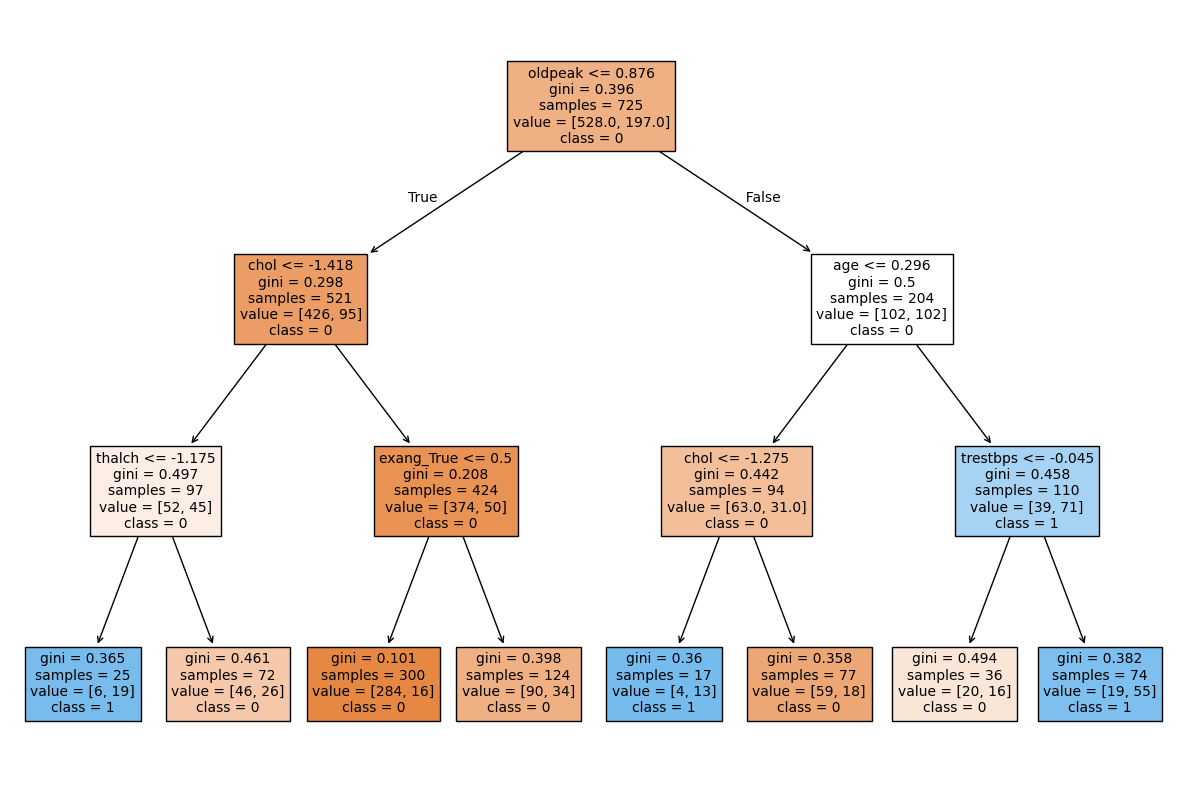

In [ ]:
# Visualize the decision tree

plt.figure(figsize=(15, 10))
plot_tree(best_mod, feature_names=X.columns.tolist(), class_names=['0', '1'], fontsize=10, filled=True)
plt.show()

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


 - Ans - **Common Hyperparameters of Decision Tree Models:**
     
     - max_depth:- Maximum depth of the tree.
      
       Effects: Prevents overfitting if kept small; deeper trees capture more detail but may overfit.

      - min_samples_split:-   Minimum number of samples required to split a node.
       
       
        Effect: Larger values makethe tree less complex
        ,reducing variance but possibly increasing bias.


      - min_samples_leaf:- Minimum number of samples required at a leaf node.

       
        Effect: Ensures leaves have enough data, smoothing predictions and reducing overfitting

     - max_features:- Number of features considered when looking for the best split.
         
         Effect: Controls randomness; fewer features reduce overfitting but may lower accuracy



2. What is the difference between the Label encoding and One-hot encoding?

Ans-   **Label Encoding:**  
        
  - Assigns each category a unique integer (ex: Red=0, Blue=1, Green=2).
  - Simple, memory-efficient.
  - Implies an artificial order , which may mislead models.
  - Ordinal categorical variables.
  (ex: "low", "medium", "high").

**One-hot encoding**

- Creates binary columns for each category (ex: Red=[1,0,0], Blue=[0,1,0], Green=[0,0,1]).
- Avoids implying order, works well for nominal categories.
- Increases dimensionality if many categories exist.
- Nominal categorical variables (ex: "red", "blue", "green").